# COVID-19 time-series analysis

Jonathan Stickel, 2020

This purpose of this notebook (and repository) is to make available a set of time-series
analyses of COVID-19 data. Data sources are:

- https://github.com/CSSEGISandData/COVID-19 (COVID-19 data)
- https://covidtracking.com/ (COVID-19 US data)
- https://data.worldbank.org/indicator/sp.pop.totl (world populations)
- https://www.census.gov/data/tables/time-series/demo/popest/2010s-state-total.html (US populations)

By default, the COVID-19 data is grabbed from web sources directly. See arguments to functions for specifying files in your local path.

To run the entire notebook, click `Cell` from the menu above and then `Run All`.

Dependencies are:

- `numpy`
- `pandas`
- `matplotlib`
- `cvxopt`
- `scikit.datasmooth` (can be pip installed)

Also, `covid19ts` and `covid_plots` are part of this repository.

Open this link in a new tab (right-click, "open link in new tab") for a web-based "live" notebook (it may take awhile to load, be patient):
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/jjstickel/covid-19_ts_analysis.git/master?filepath=analyze_covid_time_series_notebook.ipynb)


In [1]:
# import modules
import numpy as np
# locally defined modules
from covid19ts import covid19_global, covid19_ctp
import covid_plots as cvp

# User input

Put up to 7 countries of interest in the `countries` list. Must be the same name used in the J-H global files, and (at the moment), it must be a single entry in the file (e.g., China has multiple entries and will cause an Exception). At the moment, `US` must be in the list because it is included in all of the US plots.

In [2]:
countries = ["US", "Italy", "Spain", "Sweden", "Russia", "Brazil"]

Put up to 6 US states in the `US_locs` list. 

In [3]:
US_locs = ["Colorado", "California", "Arizona", "Florida", "New York", "Texas"]

Read in COVID-19 timeseries data for the locations specified and perform these operations:
- normalize cases to be per capita
- smooth the cases data
- set time-zero for each location and shift elapsed time in days
- determine rates (i.e., the derivative) for cases

In [4]:
# global data
lmbd = 5e-5 # smoothing parameter, larger means more smooth
corona = covid19_global(countries, lmbd=lmbd)
# extract common variables for ease-of-use
mult = corona["mult"]
nctry = len(countries)
dates = corona["dates"]
lastday = dates[-1]
# US data
nUSloc = len(US_locs)
coronaUS_ctp = covid19_ctp(US_locs, lastday, lmbd=lmbd)

/Users/jstickel/Documents/stuff/covid-19/covid-19_ts_analysis/covid19ts.py:249: RuntimeWarning: divide by zero encountered in true_divide
  locd["cfr"] = locd["death"]/locd["positive"]
/Users/jstickel/Documents/stuff/covid-19/covid-19_ts_analysis/covid19ts.py:249: RuntimeWarning: invalid value encountered in true_divide
  locd["cfr"] = locd["death"]/locd["positive"]


*Estimate* "active" cases by presuming all confirmed cases have recovered or died in an aeverage number of days. Estimate of recovery time from:
- https://www.thelancet.com/journals/laninf/article/PIIS1473-3099(20)30243-7/fulltext
- https://towardsdatascience.com/visual-notes-from-singapores-first-100-fully-recovered-covid-19-patients-aad7f2e1d0a0

Unfortunately, recovered data is really poor, and so directly calculating active cases is not useful.

In [5]:
rectime = 14 # days, 1 day = 1 data point -- you can change this number to see the affect on estimated acive cases
for country in countries:
    ctryd = corona[country]
    ctryd["acvest_pc"] = ctryd["cnf_pc"].copy()
    ctryd["acvest_pc"][rectime:] = ctryd["acvest_pc"][rectime:] - ctryd["cnf_pc"][:-rectime]
for loc in coronaUS_ctp["locs"]:
    locd = coronaUS_ctp[loc]
    locd["acvest_pc"] = locd["cnf_pc"].copy()
    locd["acvest_pc"][rectime:] = locd["acvest_pc"][rectime:] - locd["cnf_pc"][:-rectime]

# Plotting

In [6]:
# plot setup
dbf = 100 # days before today the time axes
cvp.rcParams.update({'font.size': 14})
cvp.fw = 8
cvp.fh = 6
#cvp.critlow_readable(corona) # provide convenient readable terms for time labeling

# Per capita cases (confirmed and deaths) with elapsed number of days from a specified time zero as indicated in the x-axis

## Global

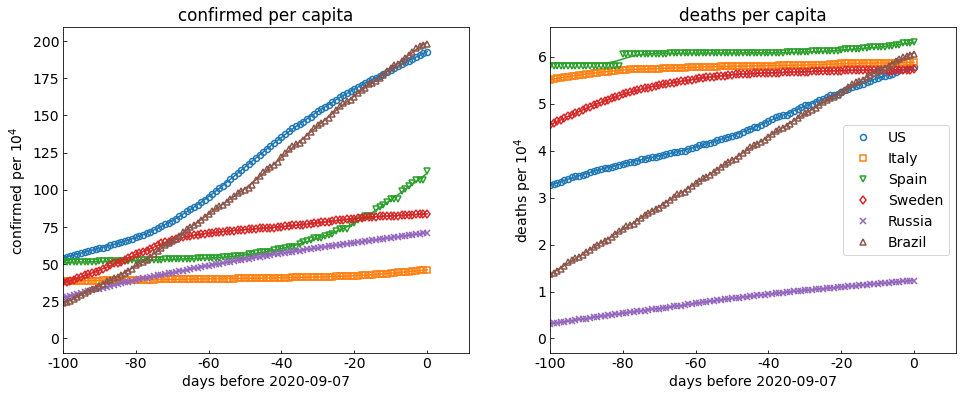

In [7]:
cvp.per_capita_global_plot(corona, lastday, days_before=dbf)

The US has a lot more confirmed per-capita cases than many countries now. This could be attributed to more testing at this point. Deaths are still lower than some countires, but rising. See rate plots directly below.

## US

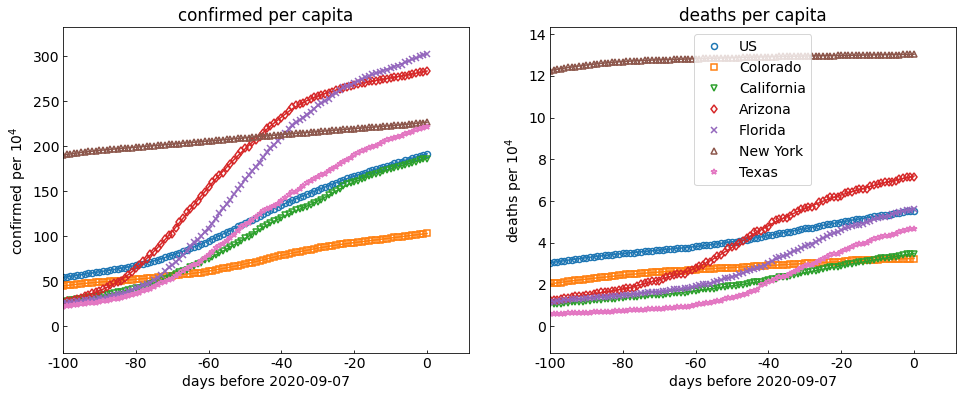

In [8]:
cvp.per_capita_US_plot(coronaUS_ctp, lastday, days_before=dbf)

US local per capita data. Although cases are rising now in some states, deaths remain low compared to New York.

# Per capita growth rates (confirmed and deaths)

## Global

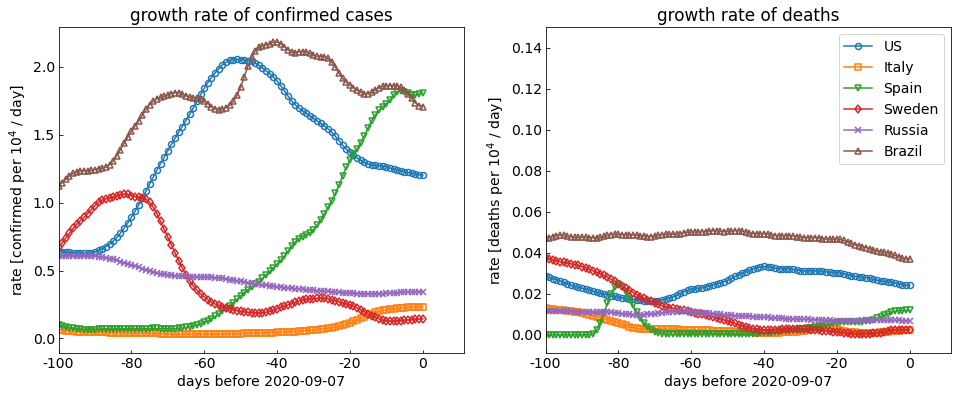

In [9]:
cvp.rate_global_plot(corona, lastday, days_before=dbf)

Growth rate is the derivative of the cases (i.e., instantaneous slope for each day). Rates for many countries have now decreased from their peak but have continued linear growth (i.e., a flat rate). 

## US

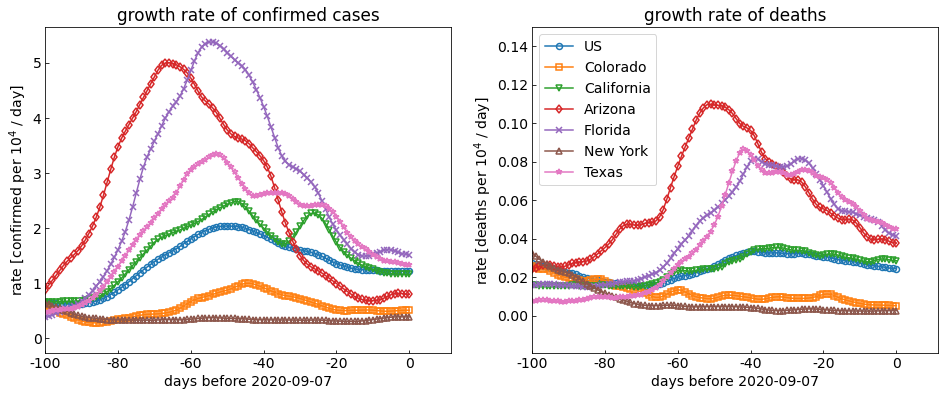

In [10]:
cvp.rate_US_plot(coronaUS_ctp, lastday, days_before=dbf)

US local rate data. Again, while the rate of increased cases are high in many states, the rate of deaths remain low compared to New York in April.

# Active cases, hospitalizations, tests, and case fatality ratio (CFR)

## Global

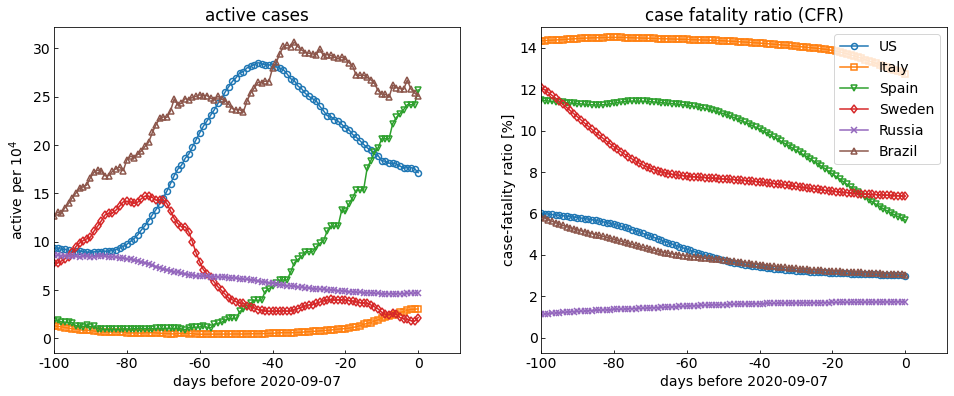

In [11]:
cvp.active_CFR_global_plot(corona, lastday, days_before=dbf)

Have we peaked? A curve of active cases help us answer this. While an initial peak ocurred a couple months ago, we are now clearly have a second wave.

The "case fatality ratio", or *CFR*, is an indication of how deadly a disease is. It is only an indication because it is limited by how many actual cases are measured and *confirmed*. Here, we see that the US is doing pretty good compared to other countries. Generally, more testing increases the denominator of the ratio and makes the CFR *lower*. (Note: the CFR is commonly called the case fatality *rate*. The use of the word rate here is technically incorrect---rate refers to something changing over *time*. [More info here](https://ourworldindata.org/coronavirus?fbclid=IwAR3zOvtt7gqkhitoHJ_lXDr3eDeE_JPtfukpOkY94PSaBm_hmrMvWCXWFpg#what-do-we-know-about-the-risk-of-dying-from-covid-19))

## US

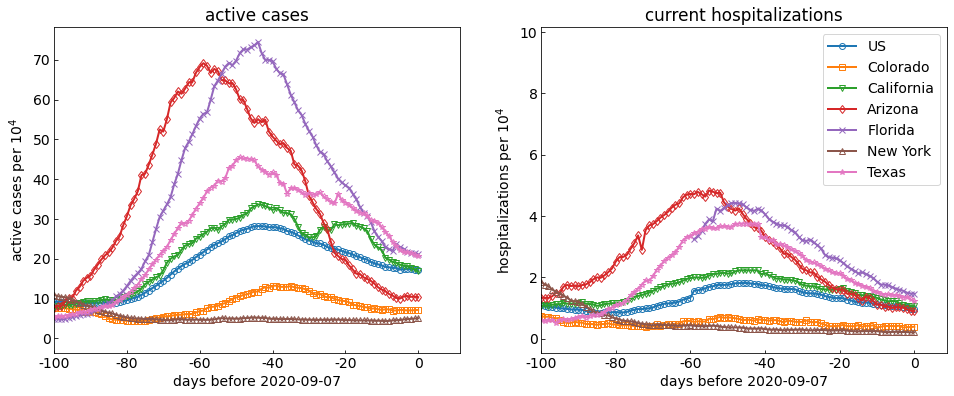

In [12]:
cvp.active_hosp_US_plot(coronaUS_ctp, lastday, days_before=dbf)

The Covid Tracking Project has data on hospitalizations by US state. I find it informative to plot hospitalizations next to active cases. While active cases in Arizona and Florida now rivals New York in April, hospitalizations are still less than half (per capita). It looks like the second wave in Arizona has peaked.

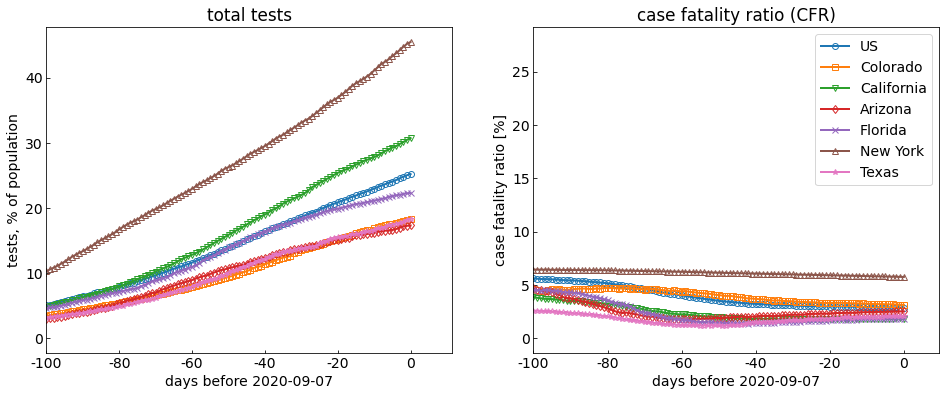

In [13]:
cvp.tests_CFR_US_plot(coronaUS_ctp, lastday, days_before=dbf)

US total tests and CFR. While testing has increased, the slopes are not as high as those of active cases in places like Arizona and Florida, and so increased testing cannot fully explain the increased number of cases.